In [2]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(ggpubr)
library(DOSE)
library(ggsci)
library(wesanderson)
library(rstatix)
library(ggprism)

In [3]:
lamin.dapi <- read.csv("~/SIRT6/HiC/Data/lamin_filt_dapi.csv")
nucleolin.dapi <- read.csv("~/SIRT6/HiC/Data/nucleolin_filt_dapi.csv")

In [4]:
nucl.dapi <- select(nucleolin.dapi, Area_um, Metadata_Mouse, AreaShape_Eccentricity, Genotype, Group)
lam.dapi <- select(lamin.dapi, Area_um, Metadata_Mouse, AreaShape_Eccentricity, Genotype, Group)

In [5]:
dapi <- rbind(nucl.dapi, lam.dapi)

In [6]:
dapi <- dapi %>%
    group_by(Group, Genotype) %>%
    mutate(Area_um.show = as.numeric(
                        between(Area_um, quantile(Area_um)[2] - 1.5*IQR(Area_um), 
                                         quantile(Area_um)[4] + 1.5*IQR(Area_um))))

In [7]:
dapi$Group <- factor(dapi$Group, levels = c('young', 'mid-aged', 'old'))
dapi$Genotype <- factor(dapi$Genotype, levels = c('WT', 'KO'))

In [8]:
pair.comp3 <- dapi %>%
    rstatix::group_by(Genotype) %>%
    rstatix::pairwise_wilcox_test(Area_um ~ Group) %>%
    rstatix::adjust_pvalue(p.col = "p", method = "BH") %>%
    rstatix::add_significance(p.col = "p.adj") %>% 
    rstatix::add_xy_position(x = "Group", dodge = 0.5)

pair.comp3

Genotype .y.     group1   group2   n1   n2   statistic p        p.adj    
1 WT       Area_um young    mid-aged 5428 7190 19207408  1.31e-01 1.310e-01
2 WT       Area_um young    old      5428 6003 15221479  1.23e-09 7.380e-09
3 WT       Area_um mid-aged old      7190 6003 20464976  3.02e-07 9.060e-07
4 KO       Area_um young    mid-aged 3018 4588  6600712  5.75e-04 8.625e-04
5 KO       Area_um young    old      3018 3237  4541891  1.57e-06 3.140e-06
6 KO       Area_um mid-aged old      4588 3237  7212879  3.10e-02 3.720e-02
  p.adj.signif y.position groups   <NA>  <NA>     <NA>     <NA>  <NA>     xmin
1 ns           198.4145   young    young mid-aged young    young mid-aged 1   
2 ****         207.4242   mid-aged old   old      mid-aged old   old      1   
3 ****         216.4339   young    young mid-aged young    young mid-aged 2   
4 ***          200.7085   mid-aged old   old      mid-aged old   old      1   
5 ****         209.7182   young    young mid-aged young    young mid-aged 1   
6 *            218.7279   mid-aged old   old      mid-aged old   old      2   
  xmax
1 2   
2 3   
3 3   
4 2   
5 3   
6 3

In [9]:
pair.comp3 <- dapi %>%
    rstatix::group_by(Group) %>%
    rstatix::pairwise_wilcox_test(Area_um ~ Genotype) %>%
    rstatix::adjust_pvalue(p.col = "p", method = "BH") %>%
    rstatix::add_significance(p.col = "p.adj") %>% 
    add_x_position(x = "Group")

print(pair.comp3)

p.area <- ggplot(dapi %>% filter(Area_um.show > 0), aes(y = Area_um, x = Group))+
    geom_violin(aes(fill = Genotype), alpha = 0.7)+
    geom_boxplot(aes(fill = Genotype), , alpha = 0.7,
                 width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA)+
    scale_y_continuous(name = expression(paste("Area, ", mu*m^2)), 
                       breaks = seq(10, 100, 20), limits = c(10, 90))+
    scale_fill_manual(values = c('tan', 'gray27')) +
    scale_x_discrete(name = NULL, labels = c('Young', 'Adult', 'Old'))+
    annotate("text", x=1.8, y=85.5, label= "ANOVA [Genotype]: p = 0.024", size = 4)+
    #add_pvalue(pair.comp3, y.position = c(85, 75, 75),
    #           tip.length = 0.01, 
    #           bracket.nudge.y = 0.0003,
    #           xmin = "xmin", 
    #           xmax = "xmax",
    #           label.size = 4, 
    #           bracket.size = 0.6)+
    theme_dose(18)+theme(axis.text.x=element_text(color = "black", angle=45, vjust=.8, hjust=0.8))

# A tibble: 3 x 13
  Group .y.   group1 group2    n1    n2 statistic        p    p.adj p.adj.signif
  <fct> <chr> <chr>  <chr>  <int> <int>     <dbl>    <dbl>    <dbl> <chr>       
1 young Area~ WT     KO      5428  3018  7502480. 1.45e-10 1.45e-10 ****        
2 mid-~ Area~ WT     KO      7190  4588 14006881  1.91e-43 5.73e-43 ****        
3 old   Area~ WT     KO      6003  3237  8512825  8   e-23 1.20e-22 ****        
# i 3 more variables: x <dbl>, xmin <dbl>, xmax <dbl>


In [11]:
theme_custom <- function(font.size = 12) {
    ggplot2::theme_bw(base_size = font.size) +
        ggplot2::theme(
            panel.grid.major = ggplot2::element_line(colour = "grey90"),
            panel.grid.minor = ggplot2::element_blank(),
            legend.key = ggplot2::element_blank(),
            strip.background = ggplot2::element_rect(fill = "grey85", colour = "grey50"),
            plot.title = ggplot2::element_text(hjust = 0.5)
        )
}

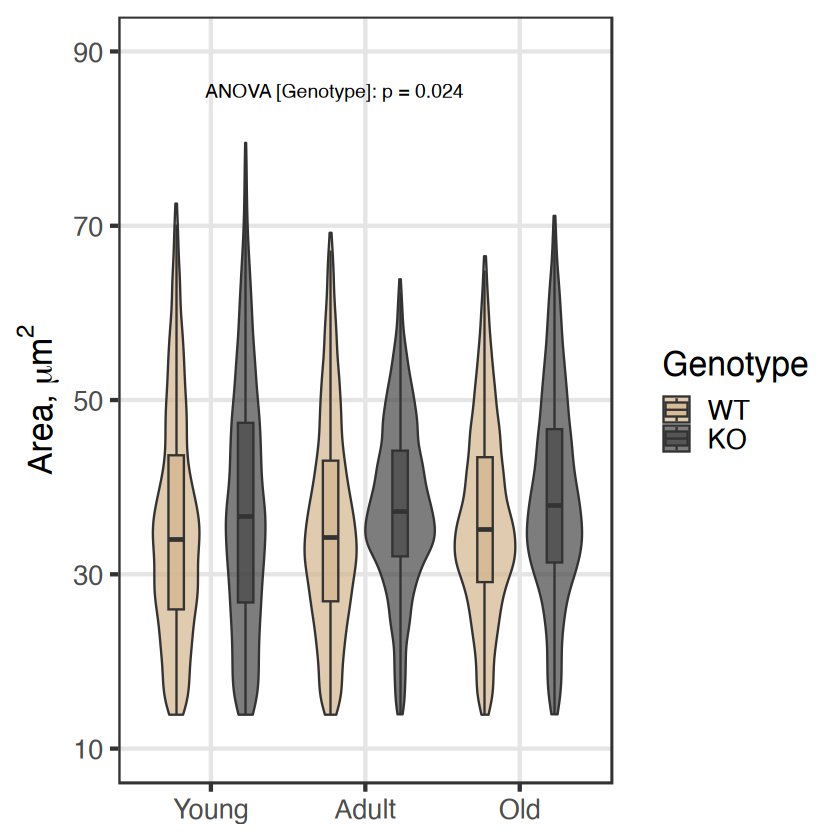

In [12]:
p.area + theme_custom(20)

In [13]:
meta_table <- dapi %>% group_by(Genotype, Group) %>% count(Metadata_Mouse)
meta_table$Genotype <- gsub("KO", "S6-KO", meta_table$Genotype)
colnames(meta_table) <- c('Genotype', 'Group', 'Mouse ID', 'N cells')
meta_table

Genotype,Group,Mouse ID,N cells
<chr>,<fct>,<int>,<int>
WT,young,4,966
WT,young,5,894
WT,young,6,887
WT,young,13,910
WT,young,16,564
WT,young,19,1207
WT,mid-aged,8,1693
WT,mid-aged,14,1428
WT,mid-aged,21,1776


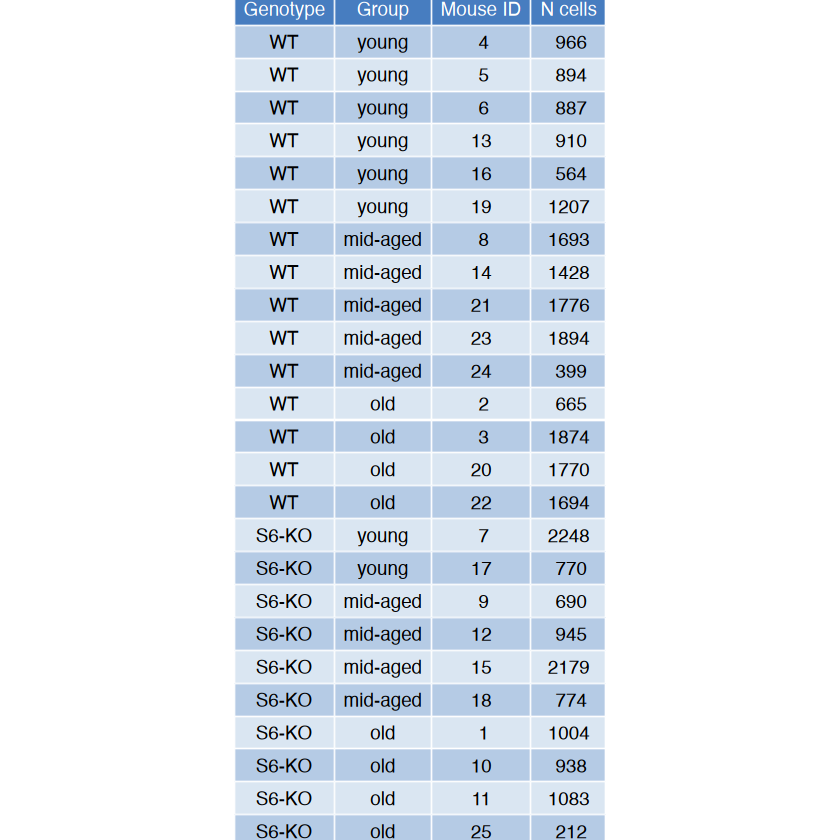

In [14]:
ggtexttable(meta_table, rows = NULL, theme = ttheme("mBlue"))